In [1]:
"""
# 02 · Grad-CAM and Saliency Maps

En este notebook vamos a estudiar métodos básicos de interpretabilidad visual para modelos de clasificación de imágenes.

El objetivo es visualizar qué partes de una imagen influyen en la predicción de una red neuronal.

Vamos a trabajar con dos enfoques:

- "Saliency Maps:" muestran qué píxeles afectan más la predicción según el gradiente de la salida respecto de la imagen.
- "Grad-CAM:" usa activaciones y gradientes de una capa convolucional para generar un mapa de importancia espacial.

Aunque usaremos el dataset "digits" como ejemplo reproducible, estas herramientas son importantes para problemas de scientific imaging como:

- análisis de microCT,
- imágenes de neutrones,
- defect detection,
- clasificación de fases,
- texturas de materiales,
- modelos aplicados a imágenes médicas o científicas.

## Objetivos del notebook

Al finalizar este notebook deberíamos poder:

- entrenar una CNN simple en PyTorch,
- calcular saliency maps,
- implementar una versión básica de Grad-CAM,
- visualizar mapas de activación sobre imágenes,
- interpretar qué regiones usa el modelo para tomar decisiones.
"""

'\n# 02 · Grad-CAM and Saliency Maps\n\nEn este notebook vamos a estudiar métodos básicos de interpretabilidad visual para modelos de clasificación de imágenes.\n\nEl objetivo es visualizar qué partes de una imagen influyen en la predicción de una red neuronal.\n\nVamos a trabajar con dos enfoques:\n\n- "Saliency Maps:" muestran qué píxeles afectan más la predicción según el gradiente de la salida respecto de la imagen.\n- "Grad-CAM:" usa activaciones y gradientes de una capa convolucional para generar un mapa de importancia espacial.\n\nAunque usaremos el dataset "digits" como ejemplo reproducible, estas herramientas son importantes para problemas de scientific imaging como:\n\n- análisis de microCT,\n- imágenes de neutrones,\n- defect detection,\n- clasificación de fases,\n- texturas de materiales,\n- modelos aplicados a imágenes médicas o científicas.\n\n## Objetivos del notebook\n\nAl finalizar este notebook deberíamos poder:\n\n- entrenar una CNN simple en PyTorch,\n- calcular sal

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")
print(f"Figures directory: {FIGURES_DIR}")

PyTorch version: 2.10.0+cpu
Selected device: cpu
Figures directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures


In [3]:
"""
## 1. Carga y preparación del dataset

Usaremos nuevamente el dataset "digits".

A diferencia del notebook anterior, ahora necesitamos conservar la estructura espacial de la imagen.

Por eso vamos a representar cada imagen con forma:

#text
(batch, channels, height, width)
"""

'\n## 1. Carga y preparación del dataset\n\nUsaremos nuevamente el dataset "digits".\n\nA diferencia del notebook anterior, ahora necesitamos conservar la estructura espacial de la imagen.\n\nPor eso vamos a representar cada imagen con forma:\n\n#text\n(batch, channels, height, width)\n'

In [4]:

## Celda 4 — Código

#python
# ------------------------------------------------------------
# 02 · Load dataset
# ------------------------------------------------------------

digits = load_digits()

X = digits.images.astype(np.float32)
y = digits.target.astype(np.int64)

# Normalize from [0, 16] to [0, 1]
X = X / 16.0

# Add channel dimension: (N, H, W) -> (N, C, H, W)
X = X[:, None, :, :]

class_names = [str(c) for c in digits.target_names]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

X shape: (1797, 1, 8, 8)
y shape: (1797,)
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


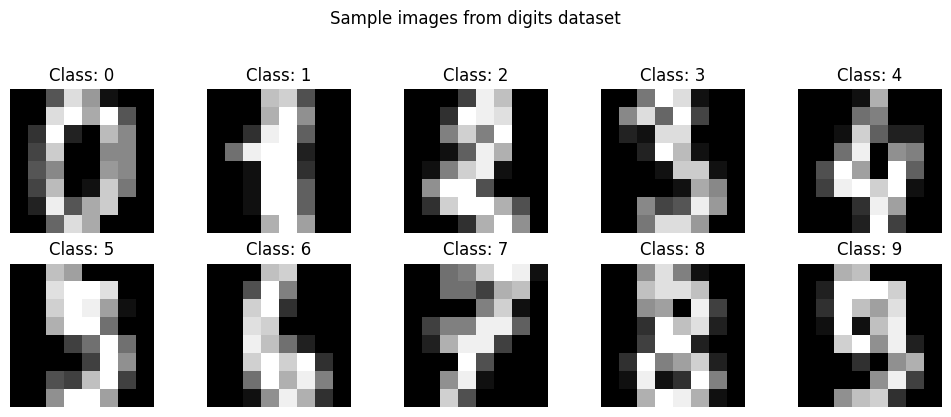

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_digits_samples_for_explainability.png


In [5]:
# ------------------------------------------------------------
# 03 · Visualize sample images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i, 0], cmap="gray")
    ax.set_title(f"Class: {y[i]}")
    ax.axis("off")

plt.suptitle("Sample images from digits dataset", y=1.03)
plt.tight_layout()

out = FIGURES_DIR / "02_digits_samples_for_explainability.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [6]:
"""
## 2. División en train, validation y test

Usamos la misma lógica de evaluación:

- entrenamiento para ajustar pesos,
- validación para monitorear el entrenamiento,
- test para evaluación final.

En interpretabilidad, es importante aplicar los métodos sobre datos no vistos por el modelo.
"""

'\n## 2. División en train, validation y test\n\nUsamos la misma lógica de evaluación:\n\n- entrenamiento para ajustar pesos,\n- validación para monitorear el entrenamiento,\n- test para evaluación final.\n\nEn interpretabilidad, es importante aplicar los métodos sobre datos no vistos por el modelo.\n'

In [7]:
# ------------------------------------------------------------
# 04 · Train / validation / test split
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1257, 1, 8, 8) (1257,)
Val  : (270, 1, 8, 8) (270,)
Test : (270, 1, 8, 8) (270,)


In [43]:
# ------------------------------------------------------------
# 05 · Create DataLoaders
# ------------------------------------------------------------

batch_size = 32

X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)
X_test_t  = torch.from_numpy(X_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 40
Val batches  : 9
Test batches : 9


In [20]:
"""
## 3. Definición de una CNN simple

Para Grad-CAM necesitamos una red convolucional.

Vamos a usar una CNN pequeña con dos bloques convolucionales.

La primera parte extrae mapas de características espaciales. La segunda parte clasifica esos mapas en una de las 10 clases.
"""

'\n## 3. Definición de una CNN simple\n\nPara Grad-CAM necesitamos una red convolucional.\n\nVamos a usar una CNN pequeña con dos bloques convolucionales.\n\nLa primera parte extrae mapas de características espaciales. La segunda parte clasifica esos mapas en una de las 10 clases.\n'

In [44]:
# ------------------------------------------------------------
# 06 · Define simple CNN model
# ------------------------------------------------------------

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        feature_maps = self.features(x)
        logits = self.classifier(feature_maps)
        return logits


model = SmallCNN().to(device)

print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [45]:
# ------------------------------------------------------------
# 07 · Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [46]:
"""
## 4. Funciones de entrenamiento y evaluación

Antes de calcular mapas de saliencia o Grad-CAM, necesitamos entrenar el modelo.

Usaremos funciones reutilizables para:

- entrenar una epoch,
- evaluar el modelo,
- guardar métricas de loss y accuracy.
"""

'\n## 4. Funciones de entrenamiento y evaluación\n\nAntes de calcular mapas de saliencia o Grad-CAM, necesitamos entrenar el modelo.\n\nUsaremos funciones reutilizables para:\n\n- entrenar una epoch,\n- evaluar el modelo,\n- guardar métricas de loss y accuracy.\n'

In [47]:
# ------------------------------------------------------------
# 08 · Train one epoch
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [48]:
# ------------------------------------------------------------
# 09 · Evaluate model
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probs, dim=1)

            running_loss += loss.item() * X_batch.size(0)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

            all_labels.extend(y_batch.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "labels": np.array(all_labels),
        "predictions": np.array(all_preds),
        "probabilities": np.array(all_probs)
    }

In [26]:
"""
## 5. Entrenamiento de la CNN

Entrenamos la CNN durante un número moderado de epoch.

El objetivo no es maximizar el rendimiento, sino obtener un modelo suficientemente bueno para aplicar métodos de interpretabilidad.
"""

'\n## 5. Entrenamiento de la CNN\n\nEntrenamos la CNN durante un número moderado de epoch.\n\nEl objetivo no es maximizar el rendimiento, sino obtener un modelo suficientemente bueno para aplicar métodos de interpretabilidad.\n'

In [49]:
# ------------------------------------------------------------
# 10 · Train CNN
# ------------------------------------------------------------

n_epochs = 30

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1:03d}/{n_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f}"
        )

Epoch [005/30] | Train Loss: 0.1208 | Train Acc: 0.9554 | Val Loss: 0.1558 | Val Acc: 0.9593
Epoch [010/30] | Train Loss: 0.0372 | Train Acc: 0.9912 | Val Loss: 0.1372 | Val Acc: 0.9519
Epoch [015/30] | Train Loss: 0.0181 | Train Acc: 0.9952 | Val Loss: 0.0902 | Val Acc: 0.9667
Epoch [020/30] | Train Loss: 0.0096 | Train Acc: 0.9976 | Val Loss: 0.0849 | Val Acc: 0.9778
Epoch [025/30] | Train Loss: 0.0023 | Train Acc: 1.0000 | Val Loss: 0.0961 | Val Acc: 0.9778
Epoch [030/30] | Train Loss: 0.0013 | Train Acc: 1.0000 | Val Loss: 0.1028 | Val Acc: 0.9815


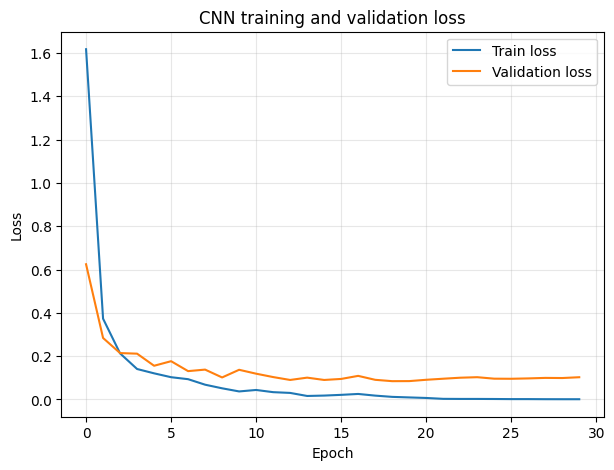

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_cnn_training_validation_loss.png


In [50]:
# ------------------------------------------------------------
# 11 · Plot training curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN training and validation loss")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "02_cnn_training_validation_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [51]:
# ------------------------------------------------------------
# 12 · Evaluate on test set
# ------------------------------------------------------------

test_metrics = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['accuracy']:.4f}")

Test loss     : 0.0647
Test accuracy : 0.9852


In [53]:
"""
## 6. Saliency maps

Un saliency map muestra qué píxeles de la imagen influyen más en la predicción del modelo.

La idea es calcular el gradiente del score de una clase respecto de la imagen de entrada:

\[
\frac{\partial score}{\partial image}
\]

Si un píxel tiene un gradiente alto, significa que pequeños cambios en ese píxel pueden afectar mucho la predicción.

En scientific imaging, esto puede ayudar a identificar si el modelo está usando regiones físicamente relevantes o artefactos no deseados.
"""

'\n## 6. Saliency maps\n\nUn saliency map muestra qué píxeles de la imagen influyen más en la predicción del modelo.\n\nLa idea es calcular el gradiente del score de una clase respecto de la imagen de entrada:\n\n\\[\n\x0crac{\\partial score}{\\partial image}\n\\]\n\nSi un píxel tiene un gradiente alto, significa que pequeños cambios en ese píxel pueden afectar mucho la predicción.\n\nEn scientific imaging, esto puede ayudar a identificar si el modelo está usando regiones físicamente relevantes o artefactos no deseados.\n'

In [54]:
# ------------------------------------------------------------
# 13 · Saliency map function
# ------------------------------------------------------------

def compute_saliency_map(model, image_tensor, target_class=None, device="cpu"):
    """
    Compute a simple gradient-based saliency map.

    Parameters
    ----------
    model : torch.nn.Module
        Trained classification model.
    image_tensor : torch.Tensor
        Input image with shape (1, 1, H, W).
    target_class : int or None
        Class used to compute the gradient. If None, use predicted class.
    device : str or torch.device
        Computation device.

    Returns
    -------
    saliency : np.ndarray
        Saliency map with shape (H, W).
    predicted_class : int
        Predicted class.
    confidence : float
        Softmax confidence for predicted class.
    """

    model.eval()

    image_tensor = image_tensor.clone().detach().to(device)
    image_tensor.requires_grad_(True)

    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1)

    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, predicted_class].item()

    if target_class is None:
        target_class = predicted_class

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    saliency = image_tensor.grad.abs().detach().cpu().numpy()[0, 0]

    # Normalize to [0, 1]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    return saliency, predicted_class, confidence

In [55]:
# ------------------------------------------------------------
# 14 · Compute saliency map for one test image
# ------------------------------------------------------------

sample_idx = 0

image = X_test_t[sample_idx:sample_idx + 1]
true_label = y_test_t[sample_idx].item()

saliency, pred_label, confidence = compute_saliency_map(
    model=model,
    image_tensor=image,
    target_class=None,
    device=device
)

print("True label      :", true_label)
print("Predicted label :", pred_label)
print(f"Confidence      : {confidence:.4f}")

True label      : 6
Predicted label : 6
Confidence      : 1.0000


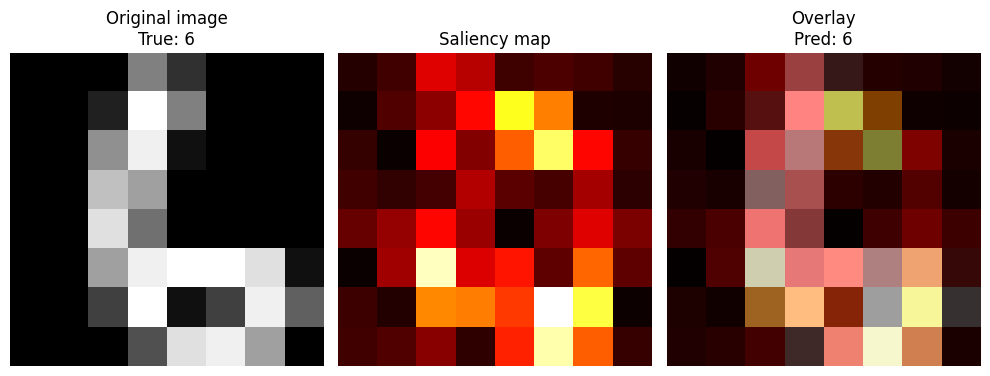

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_saliency_map_single_example.png


In [56]:
# ------------------------------------------------------------
# 15 · Visualize saliency map
# ------------------------------------------------------------

image_np = image.cpu().numpy()[0, 0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap="gray")
plt.title(f"Original image\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap="hot")
plt.title("Saliency map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_np, cmap="gray")
plt.imshow(saliency, cmap="hot", alpha=0.5)
plt.title(f"Overlay\nPred: {pred_label}")
plt.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "02_saliency_map_single_example.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [57]:
"""
## 7. Interpretación del saliency map

El saliency map resalta los píxeles donde el gradiente de la predicción es mayor.

Esto no significa necesariamente que el modelo esté “mirando” exactamente esas regiones como lo haría una persona. 
Significa que la predicción es sensible a cambios en esas posiciones.

En imágenes científicas, esta distinción es importante:

- un mapa de saliencia puede revelar regiones relevantes,
- pero también puede ser ruidoso,
- puede resaltar bordes o artefactos,
- y debe interpretarse junto con conocimiento del dominio.
"""

'\n## 7. Interpretación del saliency map\n\nEl saliency map resalta los píxeles donde el gradiente de la predicción es mayor.\n\nEsto no significa necesariamente que el modelo esté “mirando” exactamente esas regiones como lo haría una persona. \nSignifica que la predicción es sensible a cambios en esas posiciones.\n\nEn imágenes científicas, esta distinción es importante:\n\n- un mapa de saliencia puede revelar regiones relevantes,\n- pero también puede ser ruidoso,\n- puede resaltar bordes o artefactos,\n- y debe interpretarse junto con conocimiento del dominio.\n'

In [58]:
"""
## 8. Grad-CAM

Grad-CAM significa **Gradient-weighted Class Activation Mapping**.

La idea general es:

1. Pasar la imagen por la CNN.
2. Guardar las activaciones de una capa convolucional.
3. Calcular el gradiente del score de una clase respecto de esas activaciones.
4. Promediar los gradientes para obtener pesos por canal.
5. Combinar los mapas de activación usando esos pesos.
6. Aplicar ReLU para conservar solo contribuciones positivas.

Grad-CAM suele generar mapas menos ruidosos que los saliency maps porque trabaja sobre mapas de características, 
no directamente sobre píxeles individuales.
"""

'\n## 8. Grad-CAM\n\nGrad-CAM significa **Gradient-weighted Class Activation Mapping**.\n\nLa idea general es:\n\n1. Pasar la imagen por la CNN.\n2. Guardar las activaciones de una capa convolucional.\n3. Calcular el gradiente del score de una clase respecto de esas activaciones.\n4. Promediar los gradientes para obtener pesos por canal.\n5. Combinar los mapas de activación usando esos pesos.\n6. Aplicar ReLU para conservar solo contribuciones positivas.\n\nGrad-CAM suele generar mapas menos ruidosos que los saliency maps porque trabaja sobre mapas de características, \nno directamente sobre píxeles individuales.\n'

In [60]:
# ------------------------------------------------------------
# 16 · Grad-CAM function
# ------------------------------------------------------------

def compute_gradcam(model, image_tensor, target_class=None, device="cpu"):
    """
    Compute a basic Grad-CAM map for the last convolutional block.

    Parameters
    ----------
    model : torch.nn.Module
        Trained CNN model.
    image_tensor : torch.Tensor
        Input image with shape (1, 1, H, W).
    target_class : int or None
        Class used to compute Grad-CAM. If None, use predicted class.
    device : str or torch.device
        Computation device.

    Returns
    -------
    gradcam : np.ndarray
        Grad-CAM map with shape (H, W), normalized to [0, 1].
    predicted_class : int
        Predicted class.
    confidence : float
        Softmax confidence for predicted class.
    """

    model.eval()

    image_tensor = image_tensor.clone().detach().to(device)
    image_tensor.requires_grad_(True)

    activations = {}
    gradients = {}

    def forward_hook(module, input, output):
        activations["value"] = output

    def backward_hook(module, grad_input, grad_output):
        gradients["value"] = grad_output[0]

    # We use the last convolutional layer of the feature extractor.
    target_layer = model.features[2]

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1)

    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0, predicted_class].item()

    if target_class is None:
        target_class = predicted_class

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    acts = activations["value"].detach()
    grads = gradients["value"].detach()

    # Global average pooling of gradients over spatial dimensions
    weights = grads.mean(dim=(2, 3), keepdim=True)

    # Weighted combination of activation maps
    cam = (weights * acts).sum(dim=1, keepdim=True)

    # Keep only positive contributions
    cam = torch.relu(cam)

    # Resize is not needed here because feature maps are already 8x8
    cam = cam[0, 0].cpu().numpy()

    # Normalize to [0, 1]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    forward_handle.remove()
    backward_handle.remove()

    return cam, predicted_class, confidence

In [61]:
# ------------------------------------------------------------
# 17 · Compute Grad-CAM for one test image
# ------------------------------------------------------------

sample_idx = 0

image = X_test_t[sample_idx:sample_idx + 1]
true_label = y_test_t[sample_idx].item()

gradcam, pred_label, confidence = compute_gradcam(
    model=model,
    image_tensor=image,
    target_class=None,
    device=device
)

print("True label      :", true_label)
print("Predicted label :", pred_label)
print(f"Confidence      : {confidence:.4f}")

True label      : 6
Predicted label : 6
Confidence      : 1.0000


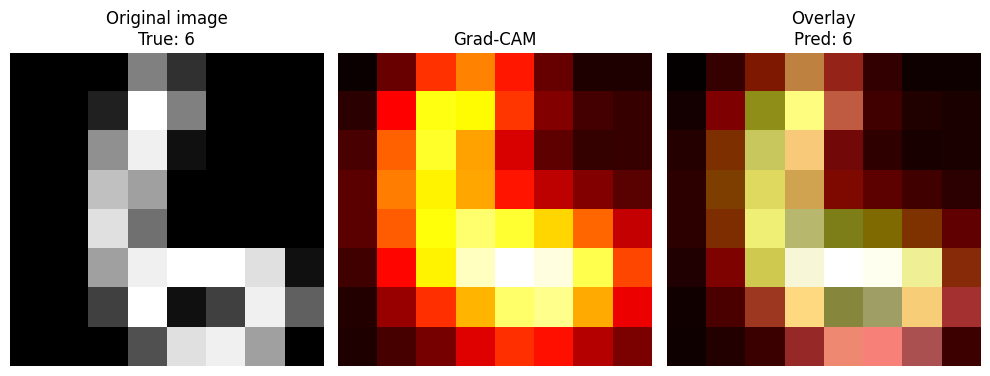

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_gradcam_single_example.png


In [62]:
# ------------------------------------------------------------
# 18 · Visualize Grad-CAM
# ------------------------------------------------------------

image_np = image.cpu().numpy()[0, 0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap="gray")
plt.title(f"Original image\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gradcam, cmap="hot")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_np, cmap="gray")
plt.imshow(gradcam, cmap="hot", alpha=0.5)
plt.title(f"Overlay\nPred: {pred_label}")
plt.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "02_gradcam_single_example.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [63]:
"""
## 9. Interpretación de Grad-CAM

En el mapa Grad-CAM, los colores más intensos indican regiones espaciales que contribuyen más positivamente a la predicción de la clase analizada.

Con el colormap `hot`:

"text
oscuro       → baja contribución
rojo/naranja → contribución intermedia
amarillo     → contribución alta
blanco       → contribución muy alta
"""

'\n## 9. Interpretación de Grad-CAM\n\nEn el mapa Grad-CAM, los colores más intensos indican regiones espaciales que contribuyen más positivamente a la predicción de la clase analizada.\n\nCon el colormap `hot`:\n\n"text\noscuro       → baja contribución\nrojo/naranja → contribución intermedia\namarillo     → contribución alta\nblanco       → contribución muy alta\n'

In [64]:
"""
## 10. Comparación entre Saliency Maps y Grad-CAM

Ambos métodos buscan explicar la predicción del modelo, pero lo hacen de forma distinta.

### Saliency Map

Calcula la sensibilidad de la predicción respecto de cada píxel de entrada.

Tiende a ser más detallado, pero también más ruidoso.

### Grad-CAM

Usa activaciones de capas convolucionales y sus gradientes.

Tiende a producir mapas más suaves y regionales.

En imágenes científicas, ambos métodos pueden ser complementarios.
"""

'\n## 10. Comparación entre Saliency Maps y Grad-CAM\n\nAmbos métodos buscan explicar la predicción del modelo, pero lo hacen de forma distinta.\n\n### Saliency Map\n\nCalcula la sensibilidad de la predicción respecto de cada píxel de entrada.\n\nTiende a ser más detallado, pero también más ruidoso.\n\n### Grad-CAM\n\nUsa activaciones de capas convolucionales y sus gradientes.\n\nTiende a producir mapas más suaves y regionales.\n\nEn imágenes científicas, ambos métodos pueden ser complementarios.\n'

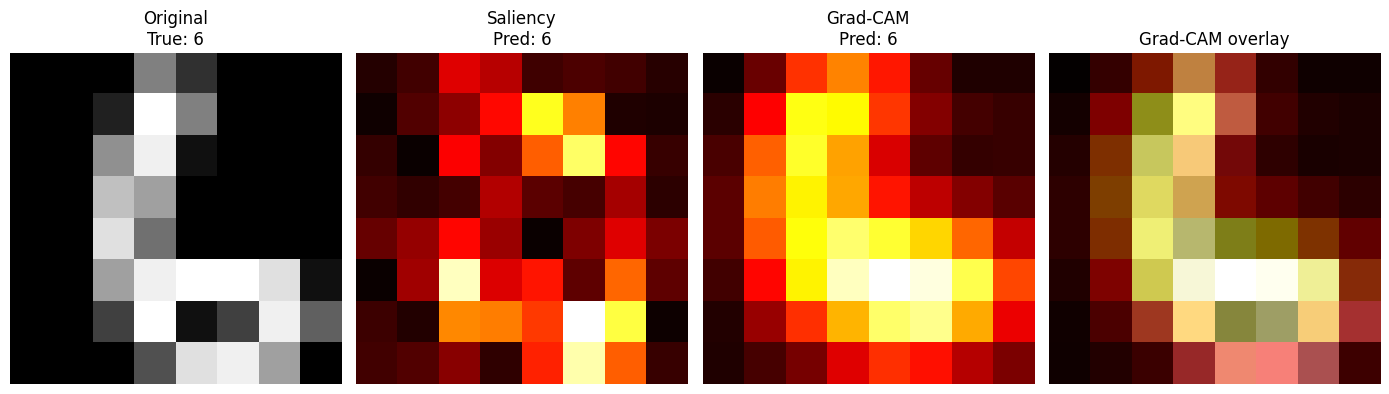

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_saliency_vs_gradcam_single_example.png


In [65]:
# ------------------------------------------------------------
# 19 · Compare original image, saliency map and Grad-CAM
# ------------------------------------------------------------

sample_idx = 0

image = X_test_t[sample_idx:sample_idx + 1]
true_label = y_test_t[sample_idx].item()

saliency, saliency_pred, saliency_conf = compute_saliency_map(
    model=model,
    image_tensor=image,
    target_class=None,
    device=device
)

gradcam, gradcam_pred, gradcam_conf = compute_gradcam(
    model=model,
    image_tensor=image,
    target_class=None,
    device=device
)

image_np = image.cpu().numpy()[0, 0]

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(image_np, cmap="gray")
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(saliency, cmap="hot")
plt.title(f"Saliency\nPred: {saliency_pred}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gradcam, cmap="hot")
plt.title(f"Grad-CAM\nPred: {gradcam_pred}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(image_np, cmap="gray")
plt.imshow(gradcam, cmap="hot", alpha=0.5)
plt.title("Grad-CAM overlay")
plt.axis("off")

plt.tight_layout()

out = FIGURES_DIR / "02_saliency_vs_gradcam_single_example.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [66]:
"""
## 11. Interpretación comparativa

El saliency map puede mostrar cambios locales muy finos, porque se calcula directamente sobre los píxeles de entrada.

Grad-CAM suele ser más útil para interpretar regiones espaciales completas, porque se basa en activaciones convolucionales.

En el caso del dataset "digits", las imágenes son muy pequeñas, por lo que los mapas tienen baja resolución espacial. 
En imágenes científicas reales de mayor tamaño, como cortes microCT o radiografías, estos métodos pueden producir visualizaciones mucho más informativas.
"""

'\n## 11. Interpretación comparativa\n\nEl saliency map puede mostrar cambios locales muy finos, porque se calcula directamente sobre los píxeles de entrada.\n\nGrad-CAM suele ser más útil para interpretar regiones espaciales completas, porque se basa en activaciones convolucionales.\n\nEn el caso del dataset "digits", las imágenes son muy pequeñas, por lo que los mapas tienen baja resolución espacial. \nEn imágenes científicas reales de mayor tamaño, como cortes microCT o radiografías, estos métodos pueden producir visualizaciones mucho más informativas.\n'

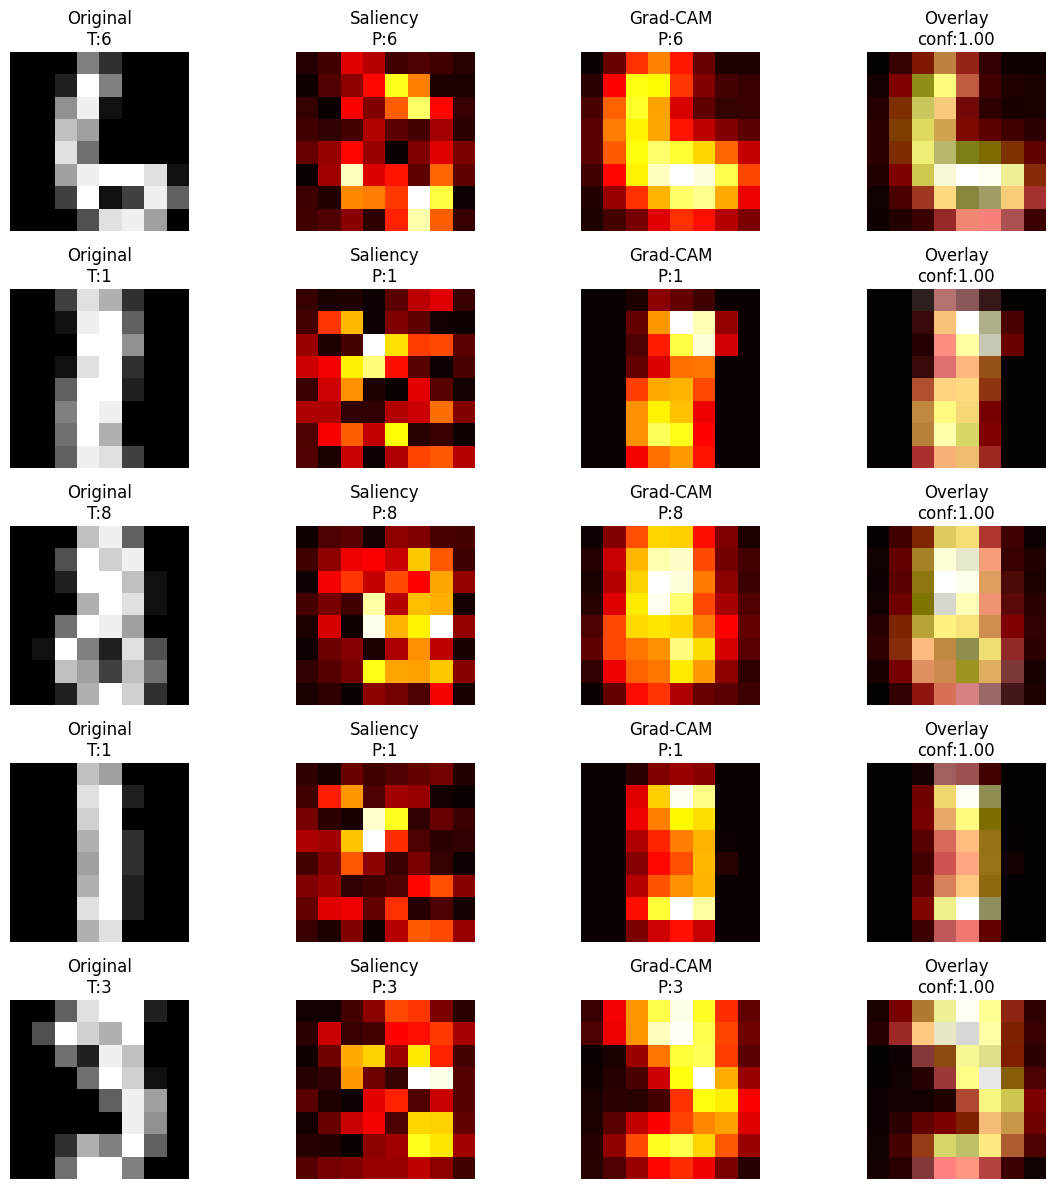

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_explanations_multiple_examples.png


In [67]:
# ------------------------------------------------------------
# 20 · Visualize explanations for multiple examples
# ------------------------------------------------------------

sample_indices = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(12, 12))

for row, sample_idx in enumerate(sample_indices):
    image = X_test_t[sample_idx:sample_idx + 1]
    true_label = y_test_t[sample_idx].item()

    saliency, saliency_pred, saliency_conf = compute_saliency_map(
        model=model,
        image_tensor=image,
        target_class=None,
        device=device
    )

    gradcam, gradcam_pred, gradcam_conf = compute_gradcam(
        model=model,
        image_tensor=image,
        target_class=None,
        device=device
    )

    image_np = image.cpu().numpy()[0, 0]

    axes[row, 0].imshow(image_np, cmap="gray")
    axes[row, 0].set_title(f"Original\nT:{true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(saliency, cmap="hot")
    axes[row, 1].set_title(f"Saliency\nP:{saliency_pred}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(gradcam, cmap="hot")
    axes[row, 2].set_title(f"Grad-CAM\nP:{gradcam_pred}")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(image_np, cmap="gray")
    axes[row, 3].imshow(gradcam, cmap="hot", alpha=0.5)
    axes[row, 3].set_title(f"Overlay\nconf:{gradcam_conf:.2f}")
    axes[row, 3].axis("off")

plt.tight_layout()

out = FIGURES_DIR / "02_explanations_multiple_examples.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [68]:
"""
## 12. Limitaciones

Los métodos de interpretabilidad visual deben usarse con cuidado.

Algunas limitaciones importantes son:

- pueden ser sensibles al preprocesamiento,
- pueden cambiar entre arquitecturas,
- pueden resaltar bordes o texturas sin significado físico,
- no prueban causalidad,
- no reemplazan validación experimental ni conocimiento experto.

En scientific imaging, estas herramientas son útiles como apoyo para inspección, pero no deben interpretarse como una 
explicación física completa del modelo.
"""

'\n## 12. Limitaciones\n\nLos métodos de interpretabilidad visual deben usarse con cuidado.\n\nAlgunas limitaciones importantes son:\n\n- pueden ser sensibles al preprocesamiento,\n- pueden cambiar entre arquitecturas,\n- pueden resaltar bordes o texturas sin significado físico,\n- no prueban causalidad,\n- no reemplazan validación experimental ni conocimiento experto.\n\nEn scientific imaging, estas herramientas son útiles como apoyo para inspección, pero no deben interpretarse como una \nexplicación física completa del modelo.\n'

In [69]:
# ------------------------------------------------------------
# 21 · Collect predictions on test set
# ------------------------------------------------------------

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

correct_indices = np.where(all_preds == all_labels)[0]
incorrect_indices = np.where(all_preds != all_labels)[0]

print("Correct predictions  :", len(correct_indices))
print("Incorrect predictions:", len(incorrect_indices))

Correct predictions  : 266
Incorrect predictions: 4


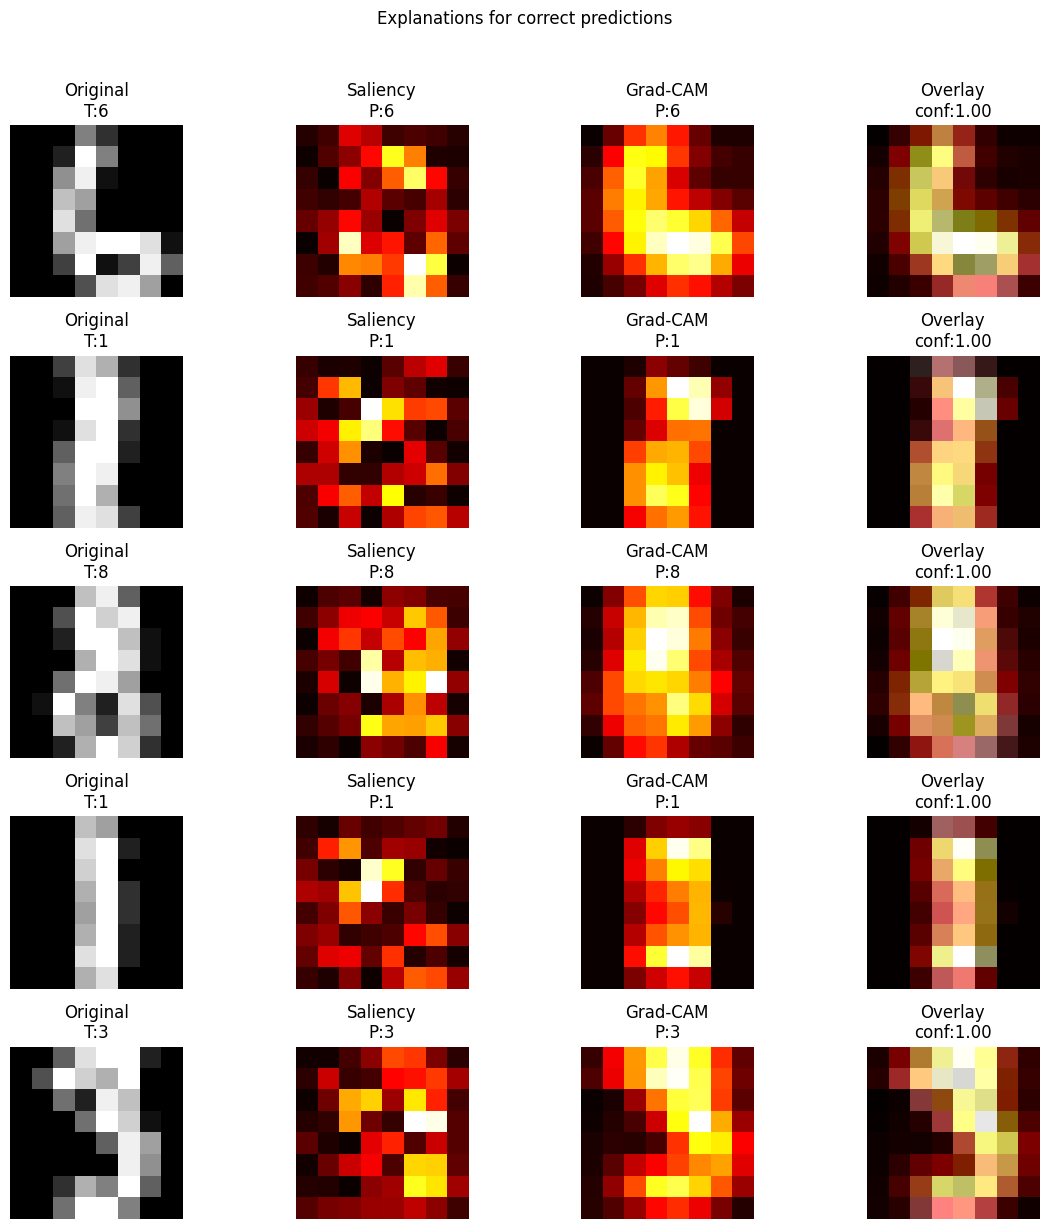

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_explanations_correct_predictions.png


In [70]:
# ------------------------------------------------------------
# 22 · Explain correct predictions
# ------------------------------------------------------------

sample_indices = correct_indices[:5]

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(12, 12))

for row, sample_idx in enumerate(sample_indices):
    image = X_test_t[sample_idx:sample_idx + 1]
    true_label = y_test_t[sample_idx].item()

    saliency, saliency_pred, saliency_conf = compute_saliency_map(
        model=model,
        image_tensor=image,
        target_class=None,
        device=device
    )

    gradcam, gradcam_pred, gradcam_conf = compute_gradcam(
        model=model,
        image_tensor=image,
        target_class=None,
        device=device
    )

    image_np = image.cpu().numpy()[0, 0]

    axes[row, 0].imshow(image_np, cmap="gray")
    axes[row, 0].set_title(f"Original\nT:{true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(saliency, cmap="hot")
    axes[row, 1].set_title(f"Saliency\nP:{saliency_pred}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(gradcam, cmap="hot")
    axes[row, 2].set_title(f"Grad-CAM\nP:{gradcam_pred}")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(image_np, cmap="gray")
    axes[row, 3].imshow(gradcam, cmap="hot", alpha=0.5)
    axes[row, 3].set_title(f"Overlay\nconf:{gradcam_conf:.2f}")
    axes[row, 3].axis("off")

plt.suptitle("Explanations for correct predictions", y=1.02)
plt.tight_layout()

out = FIGURES_DIR / "02_explanations_correct_predictions.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

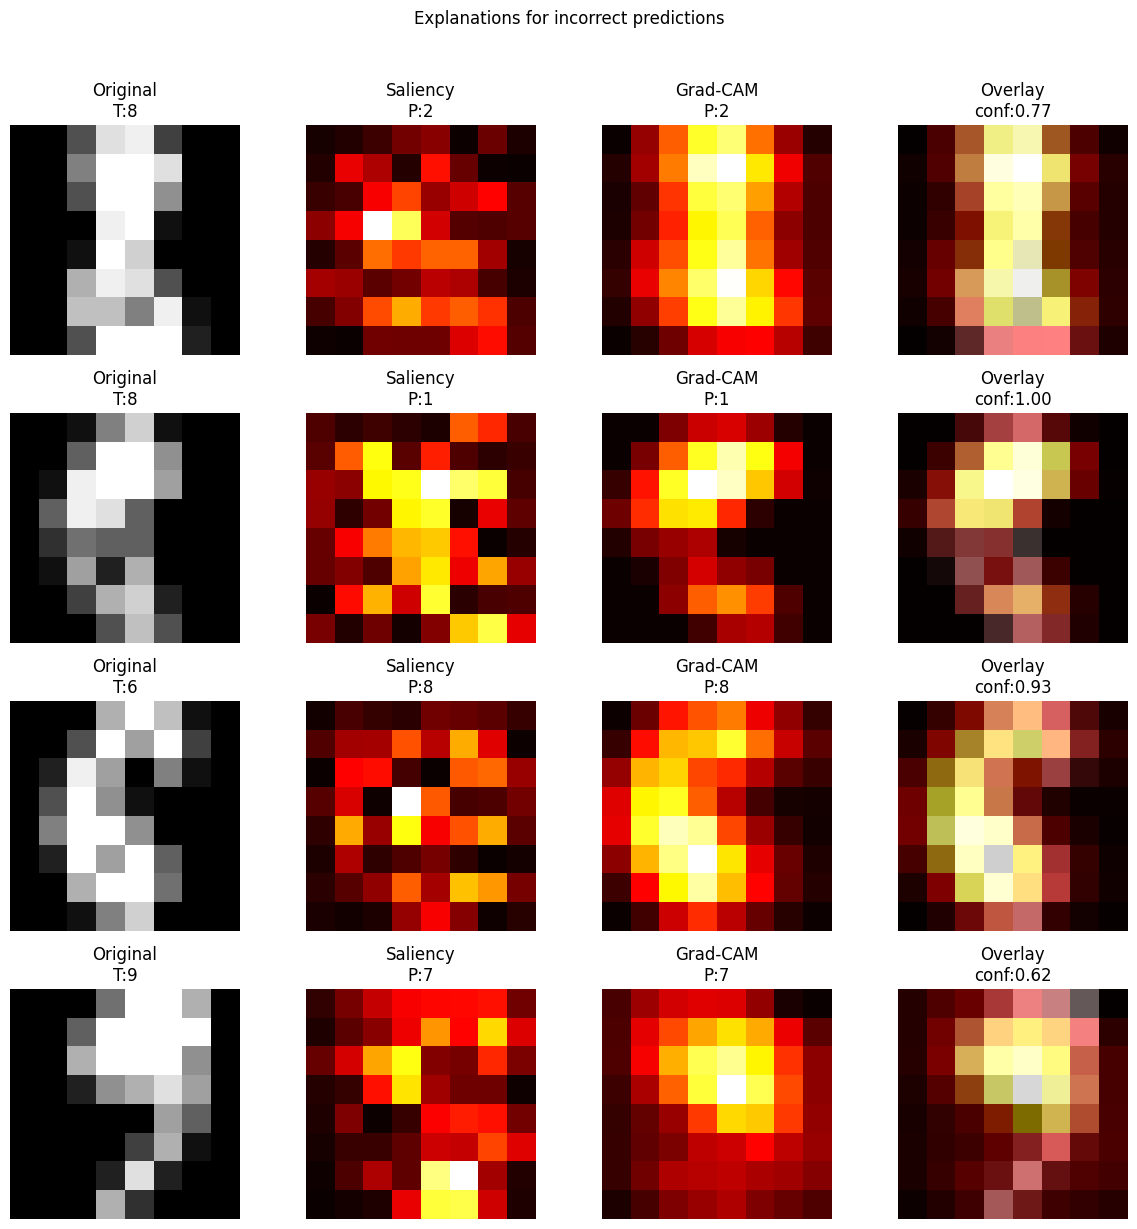

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\02_explanations_incorrect_predictions.png


In [71]:
# ------------------------------------------------------------
# 23 · Explain incorrect predictions
# ------------------------------------------------------------

if len(incorrect_indices) > 0:
    sample_indices = incorrect_indices[:5]

    fig, axes = plt.subplots(len(sample_indices), 4, figsize=(12, 12))

    for row, sample_idx in enumerate(sample_indices):
        image = X_test_t[sample_idx:sample_idx + 1]
        true_label = y_test_t[sample_idx].item()

        saliency, saliency_pred, saliency_conf = compute_saliency_map(
            model=model,
            image_tensor=image,
            target_class=None,
            device=device
        )

        gradcam, gradcam_pred, gradcam_conf = compute_gradcam(
            model=model,
            image_tensor=image,
            target_class=None,
            device=device
        )

        image_np = image.cpu().numpy()[0, 0]

        axes[row, 0].imshow(image_np, cmap="gray")
        axes[row, 0].set_title(f"Original\nT:{true_label}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(saliency, cmap="hot")
        axes[row, 1].set_title(f"Saliency\nP:{saliency_pred}")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(gradcam, cmap="hot")
        axes[row, 2].set_title(f"Grad-CAM\nP:{gradcam_pred}")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(image_np, cmap="gray")
        axes[row, 3].imshow(gradcam, cmap="hot", alpha=0.5)
        axes[row, 3].set_title(f"Overlay\nconf:{gradcam_conf:.2f}")
        axes[row, 3].axis("off")

    plt.suptitle("Explanations for incorrect predictions", y=1.02)
    plt.tight_layout()

    out = FIGURES_DIR / "02_explanations_incorrect_predictions.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved to: {out}")

else:
    print("No incorrect predictions found in the test set.")

In [72]:
"""
## 13. Correct vs incorrect explanations

Comparar explicaciones para predicciones correctas e incorrectas puede ser muy útil.

En predicciones correctas, esperamos que las regiones resaltadas coincidan razonablemente con partes informativas de la imagen.

En predicciones incorrectas, los mapas pueden ayudar a detectar:

- regiones ambiguas,
- formas incompletas,
- ruido,
- patrones visualmente similares entre clases,
- posibles errores de etiquetado.

En scientific imaging, este análisis puede ayudar a decidir si el modelo está aprendiendo señales físicas relevantes o correlaciones espurias.
"""

'\n## 13. Correct vs incorrect explanations\n\nComparar explicaciones para predicciones correctas e incorrectas puede ser muy útil.\n\nEn predicciones correctas, esperamos que las regiones resaltadas coincidan razonablemente con partes informativas de la imagen.\n\nEn predicciones incorrectas, los mapas pueden ayudar a detectar:\n\n- regiones ambiguas,\n- formas incompletas,\n- ruido,\n- patrones visualmente similares entre clases,\n- posibles errores de etiquetado.\n\nEn scientific imaging, este análisis puede ayudar a decidir si el modelo está aprendiendo señales físicas relevantes o correlaciones espurias.\n'

In [73]:
# ------------------------------------------------------------
# 24 · Save trained CNN model
# ------------------------------------------------------------

model_path = MODELS_DIR / "02_cnn_gradcam_saliency.pt"

torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\models\02_cnn_gradcam_saliency.pt


In [74]:
"""
# Conclusión final

En este notebook implementamos dos métodos básicos de interpretabilidad visual:

- **Saliency maps**
- **Grad-CAM**

Los saliency maps muestran sensibilidad píxel a píxel usando gradientes de la predicción respecto de la imagen de entrada.

Grad-CAM usa activaciones y gradientes de una capa convolucional para generar mapas de importancia espacial más suaves.

La idea central es que la interpretabilidad visual permite complementar las métricas tradicionales de evaluación.

En aplicaciones científicas, estos métodos pueden ayudar a responder preguntas como:

"text
¿Qué regiones influyen en la predicción?
¿El modelo está usando estructuras físicamente relevantes?
¿Los errores se asocian a regiones ambiguas o artefactos?
¿El modelo está aprendiendo señales útiles o atajos espurios?
"""

'\n# Conclusión final\n\nEn este notebook implementamos dos métodos básicos de interpretabilidad visual:\n\n- **Saliency maps**\n- **Grad-CAM**\n\nLos saliency maps muestran sensibilidad píxel a píxel usando gradientes de la predicción respecto de la imagen de entrada.\n\nGrad-CAM usa activaciones y gradientes de una capa convolucional para generar mapas de importancia espacial más suaves.\n\nLa idea central es que la interpretabilidad visual permite complementar las métricas tradicionales de evaluación.\n\nEn aplicaciones científicas, estos métodos pueden ayudar a responder preguntas como:\n\n"text\n¿Qué regiones influyen en la predicción?\n¿El modelo está usando estructuras físicamente relevantes?\n¿Los errores se asocian a regiones ambiguas o artefactos?\n¿El modelo está aprendiendo señales útiles o atajos espurios?\n'

In [75]:

## Celda 40 — Código final

#python
# ------------------------------------------------------------
# 25 · End of notebook
# ------------------------------------------------------------

print("Notebook 02 completed successfully.")

Notebook 02 completed successfully.
